# LIBRARY

In [16]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

# Random forest (all features)

In [18]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_Fat']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_Fat'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [2.61172319e-02 1.41335225e-01 1.55976213e-01 ... 1.26172190e+02
 1.44216233e+02 1.53820000e+02]
Class counts : {0.0261172319401445: 1, 0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6943243806978128: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.7695964043547789: 1, 0.7937175712902675: 1, 0.914272: 1, 0.9278624147171168: 1, 0.9361240372254578: 1, 0.960596: 1, 1.03703: 1, 1.08337: 1, 1.10211: 1, 1.12023: 1, 1.12647: 1, 1.1374242649394244: 1, 1.2181847058501525: 1, 1.23591: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.40645: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.43891: 1, 1.4391140395920292: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.48557469

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [20]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.914272: 1, 0.9278624147171168: 1, 1.08337: 1, 1.12023: 1, 1.12647: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.4855746917833272: 1, 1.5850919235053809: 1, 1.60696907364178: 1, 1.6629486743368886: 1, 1.675231162552711: 1, 1.6916029807358584: 1, 1.7072039718993626: 1, 1.7178763418160568: 1, 1.729555539083382: 1, 1.7378501855288224: 1, 1.7398: 1, 1.7586866789156108: 1, 1.772913552110973: 1, 1.78031: 1, 1.78453: 1, 1.79586: 1, 1.79608: 1, 1.802109128893644: 1, 1.8404442816344064: 1, 1.84964: 1, 1.86497: 1, 1.90846: 1, 1.

In [21]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [23]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [24]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [25]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'absolute_error',
                                                      'squared_error'],
                                        'max_depth': [5, 7, 10, 15],
                                        'max_features': ['log2', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2', verbose=1)

In [26]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.8385


In [27]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 6.1227
MAE   (test): 3.5484
R²    (test): 0.8605


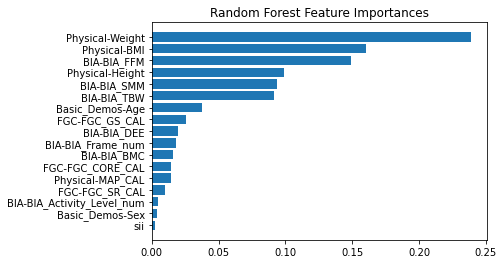

In [28]:
feature_imp(best_model, attributes)

# Random forest (reduced features)

In [ ]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [ ]:
column2drop = ['id', 'sii', 'Basic_Demos-Sex', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL', 'FGC-FGC_SR_CAL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_Frame_num']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'BIA-BIA_Fat']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['BIA-BIA_Fat'])


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [2.61172319e-02 1.41335225e-01 1.55976213e-01 ... 1.26172190e+02
 1.44216233e+02 1.53820000e+02]
Class counts : {0.0261172319401445: 1, 0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6943243806978128: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.7695964043547789: 1, 0.7937175712902675: 1, 0.914272: 1, 0.9278624147171168: 1, 0.9361240372254578: 1, 0.960596: 1, 1.03703: 1, 1.08337: 1, 1.10211: 1, 1.12023: 1, 1.12647: 1, 1.1374242649394244: 1, 1.2181847058501525: 1, 1.23591: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.40645: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.43891: 1, 1.4391140395920292: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.48557469

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [ ]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.1413352248065393: 1, 0.1559762127008266: 1, 0.2119670898622612: 1, 0.2683961382866897: 1, 0.2845367889101329: 1, 0.386662: 1, 0.414636: 1, 0.4217681622630778: 1, 0.447879: 1, 0.4825217355239406: 1, 0.502266828062643: 1, 0.530487: 1, 0.6921464117729261: 1, 0.6989912268334599: 1, 0.7464369589046154: 1, 0.914272: 1, 0.9278624147171168: 1, 1.08337: 1, 1.12023: 1, 1.12647: 1, 1.24626: 1, 1.26681: 1, 1.26814: 1, 1.37804: 1, 1.394843438253826: 1, 1.407073571447416: 1, 1.412902699076632: 1, 1.4147: 1, 1.43457: 1, 1.4610040771185189: 1, 1.4630604212994474: 1, 1.46925: 1, 1.4855746917833272: 1, 1.5850919235053809: 1, 1.60696907364178: 1, 1.6629486743368886: 1, 1.675231162552711: 1, 1.6916029807358584: 1, 1.7072039718993626: 1, 1.7178763418160568: 1, 1.729555539083382: 1, 1.7378501855288224: 1, 1.7398: 1, 1.7586866789156108: 1, 1.772913552110973: 1, 1.78031: 1, 1.78453: 1, 1.79586: 1, 1.79608: 1, 1.802109128893644: 1, 1.8404442816344064: 1, 1.84964: 1, 1.86497: 1, 1.90846: 1, 1.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [ ]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [ ]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         [ 'friedman_mse', 'absolute_error', 'squared_error'],
}

In [ ]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=KFold(                     
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='r2',  
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'absolute_error',
                                                      'squared_error'],
                                        'max_depth': [5, 7, 10, 15],
                                        'max_features': ['log2', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2', verbose=1)

In [ ]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")


── Best hyperparameters found ──────────────────────────
  n_estimators        : 500
  min_samples_split   : 5
  min_samples_leaf    : 2
  max_features        : log2
  max_depth           : 15
  criterion           : squared_error

  F1-macro (CV): 0.8385


In [ ]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nBest params : {random_search.best_params_}")
print(f"RMSE  (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE   (test): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²    (test): {r2_score(y_test, y_pred):.4f}")


Best params : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'squared_error'}
RMSE  (test): 6.1227
MAE   (test): 3.5484
R²    (test): 0.8605


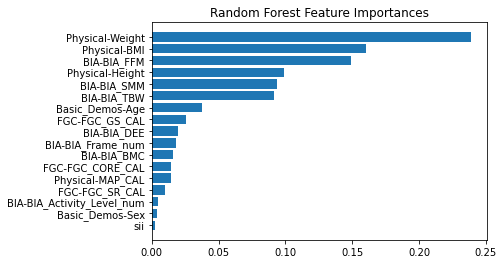

In [ ]:
feature_imp(best_model, attributes)